# **RF-DETRnano training (5-class eye segmentation)**

このノートブックでは、既存の6クラスマスクからCOCO形式のセグメンテーションデータセットを構築し、
RF-DETRnanoを事前学習済み重みでトレーニングし、raw vs fullmaxマスク後処理によるサンプル推論を実行します。

## クラス定義

このノートブックでは **conj（結膜）** と **caruncle（涙丘）** を別クラスとして扱います。

| COCO category_id (train/infer) | Class Name | 説明 |
|----------|------------|------|
| 0 | conj | 結膜 |
| 1 | caruncle | 涙丘 |
| 2 | iris_vis | 虹彩（可視部分） |
| 3 | iris_occ | 虹彩（遮蔽部分） |
| 4 | pupil_vis | 瞳孔（可視部分） |
| 5 | pupil_occ | 瞳孔（遮蔽部分） |

※ 後段で semantic mask（0=background, 1..6=foreground）にしたい場合は、`category_id + 1` にシフトしてください。

## ワークフロー

1. **データの準備**: CVAT XMLファイルから画像リストを取得
2. **COCO形式への変換**: 6クラスマスクからCOCO形式のアノテーションを生成
3. **RF-DETRトレーニング**: RF-DETRnanoモデルのトレーニング
4. **推論と可視化**: トレーニング済みモデルによる推論と結果の可視化

## 注意事項

- 入力画像リストは2つのCVAT XMLファイル（1-3000範囲）から取得されます
- このノートブックは評価CSVファイルを生成しません
- RF-DETRはCOCO形式のデータセットを使用します


In [1]:
from pathlib import Path
import json
import random
import xml.etree.ElementTree as ET

import cv2
import numpy as np

PROJECT_ROOT = Path('.').resolve()
IMAGES_DIR = PROJECT_ROOT / 'Images' / 'images'
LABEL_SEG_DIR = PROJECT_ROOT / 'Images' / 'labels_seg'

XML_EYELID = PROJECT_ROOT / 'Images' / 'eyelid_caruncle_seg_0-3000.xml'
XML_IRIS_PUPIL = PROJECT_ROOT / 'Images' / 'obb_iris_pupil_1-3000.xml'

OUTPUT_DIR = PROJECT_ROOT / 'Ablation_RFDETR'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 512
SEED = 42
VAL_RATIO = 0.2
MIN_CONTOUR_AREA = 10

# RF-DETRは0-indexedのクラスIDを期待するため、0から始める
CLASS_NAMES = {
    0: 'conj',
    1: 'caruncle',
    2: 'iris_vis',
    3: 'iris_occ',
    4: 'pupil_vis',
    5: 'pupil_occ',
}

print('OK: config loaded')


OK: config loaded


In [2]:
def load_cvat_image_names_with_id(xml_path: Path, min_id: int = 0, max_id: int = 2999):
    """
    XMLファイルから画像名とIDを取得し、指定されたID範囲でフィルタリング
    Returns: dict {image_id: image_name}
    """
    if not xml_path.exists():
        raise FileNotFoundError(xml_path)
    root = ET.parse(xml_path).getroot()
    image_dict = {}
    for img in root.findall('.//image'):
        img_id_str = img.attrib.get('id')
        name = img.attrib.get('name')
        if img_id_str is not None and name:
            try:
                img_id = int(img_id_str)
                if min_id <= img_id <= max_id:
                    image_dict[img_id] = Path(name).name
            except ValueError:
                continue
    return image_dict

# 画像ID 0-2999の範囲で画像を取得
eyelid_dict = load_cvat_image_names_with_id(XML_EYELID, min_id=0, max_id=2999)
iris_dict = load_cvat_image_names_with_id(XML_IRIS_PUPIL, min_id=0, max_id=2999)

# 和集合（union）を使用：両方のXMLファイルに含まれる全ての画像を使用
# 共通部分（intersection）ではなく、どちらかのXMLファイルに含まれていれば使用
all_dict = {**eyelid_dict, **iris_dict}  # 後から来たもので上書き（同じIDの場合）

# ID順にソート
all_names = [all_dict[img_id] for img_id in sorted(all_dict.keys())]

image_names = []
missing_images = 0
missing_masks = 0

# マスクファイルが存在しない画像も含める（空のアノテーションとして扱う）
for name in all_names:
    img_path = IMAGES_DIR / name
    stem = Path(name).stem
    mask_path = LABEL_SEG_DIR / f'{stem}_sixcls.png'
    if not img_path.exists():
        missing_images += 1
        continue
    # マスクファイルが存在しない場合も含める（空のアノテーションとして扱う）
    if not mask_path.exists():
        missing_masks += 1
    image_names.append(name)

print(f'XML eyelid images (ID 0-2999): {len(eyelid_dict)}')
print(f'XML iris/pupil images (ID 0-2999): {len(iris_dict)}')
print(f'Union (all names, ID 0-2999): {len(all_dict)}')
print(f'Intersection (ID 0-2999): {len(set(eyelid_dict.keys()) & set(iris_dict.keys()))}')
print(f'Total images (ID 0-2999): {len(image_names)}')
print(f'Missing images: {missing_images}, missing sixcls (will use empty annotations): {missing_masks}')


XML eyelid images (ID 0-2999): 2990
XML iris/pupil images (ID 0-2999): 3000
Union (all names, ID 0-2999): 3000
Intersection (ID 0-2999): 2990
Total images (ID 0-2999): 3000
Missing images: 0, missing sixcls (will use empty annotations): 1008


In [3]:
def subject_id_from_name(name: str) -> str:
    return str(name).split('-', 1)[0]

subjects = sorted({subject_id_from_name(n) for n in image_names})
rng = random.Random(SEED)
rng.shuffle(subjects)

num_val = max(1, int(len(subjects) * VAL_RATIO))
val_subjects = set(subjects[:num_val])

train_names = [n for n in image_names if subject_id_from_name(n) not in val_subjects]
val_names = [n for n in image_names if subject_id_from_name(n) in val_subjects]

print(f'Train images: {len(train_names)}')
print(f'Val images: {len(val_names)}')
print(f'Train subjects: {len({subject_id_from_name(n) for n in train_names})}')
print(f'Val subjects: {len(val_subjects)}')


Train images: 2426
Val images: 574
Train subjects: 156
Val subjects: 38


In [4]:
def contours_to_polygons(mask_255: np.ndarray, min_area: int = MIN_CONTOUR_AREA):
    contours, _ = cv2.findContours(mask_255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for cnt in contours:
        if cnt.shape[0] < 3:
            continue
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        poly = cnt.reshape(-1, 2).astype(float).flatten().tolist()
        if len(poly) >= 6:
            polygons.append(poly)
    return polygons

def mask_to_bbox(mask_255: np.ndarray):
    ys, xs = np.where(mask_255 > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x_min = int(xs.min())
    y_min = int(ys.min())
    x_max = int(xs.max())
    y_max = int(ys.max())
    return [x_min, y_min, int(x_max - x_min + 1), int(y_max - y_min + 1)]


# ===== CVAT XML -> COCO polygon helpers =====
import math
import xml.etree.ElementTree as ET

EYELID_XML = Path("Images/eyelid_caruncle_seg_0-3000.xml")
IRIS_PUPIL_XML = Path("Images/obb_iris_pupil_1-3000.xml")

# NOTE:
# - 6-class(0=background, 1..5=conj/iris_vis/iris_occ/pupil_vis/pupil_occ)は「semantic mask用」の表現です。
# - RF-DETRのCOCO(instance segmentation)学習では、背景はカテゴリに含めず、カテゴリ数は5（conj..pupil_occ）として扱うのが安全です。
# - したがって後段でsemantic maskを作るときに、推論の class_id(0..4) を (class_id+1) にシフトして ablation_yolo11_clean_final.ipynb と整合させます。
# - ここでは Caruncle を Eyelid と同じクラス(=conj/eyelid)に寄せています（1クラス最大2インスタンス想定）
# - Iris/Pupil は楕円(ellipse)を100点polygonに変換し、インスタンスsegとしてCOCOに入れます
XML_LABEL_TO_CLASS_ID = {
    # polygon
    "Eyelid": 0,
    "Caruncle": 1,
    # ellipse (vis/occ は eyelid 領域との交差で後段で分割)
    "Iris": None,
    "Pupil": None,
}

# vis/occ 分割ルール
# ユーザー要件: "楕円のうち eyelid の範囲に入っていれば vis / 入っていなければ occ"
# 直感と逆になる場合は、このフラグを反転してください。
EYELID_INSIDE_IS_VISIBLE = True

# インスタンス数の上限は設けない（必要なら後で導入）
ELLIPSE_NUM_POINTS = 100

# 6-class(0=background, 1..5=conj/iris_vis/iris_occ/pupil_vis/pupil_occ)は「semantic mask用」の表現です。
# RF-DETRのCOCO(instance segmentation)学習では背景はカテゴリに含めず、カテゴリ数は5（conj..pupil_occ）として扱います。
# 後段でsemantic maskを作るときに、推論の class_id(0..4) を (class_id+1) にシフトして ablation_yolo11_clean_final.ipynb と整合させてください。


def _parse_points_attr(points_str: str):
    """CVAT polygon points="x,y;x,y;..." -> [x0,y0,x1,y1,...]"""
    pts = []
    for token in points_str.strip().split(";"):
        token = token.strip()
        if not token:
            continue
        x_str, y_str = token.split(",")
        pts.append(float(x_str))
        pts.append(float(y_str))
    return pts


def _ellipse_to_polygon(cx: float, cy: float, rx: float, ry: float, rotation_deg: float, n: int = 100, w: int | None = None, h: int | None = None):
    """楕円パラメータ -> COCO polygon (x0,y0,...)

    CVAT ellipse: (cx,cy,rx,ry,rotation[deg])
    """
    theta = math.radians(rotation_deg % 360.0)
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)

    poly = []
    for i in range(n):
        a = 2.0 * math.pi * (i / n)
        ca = math.cos(a)
        sa = math.sin(a)

        # axis-aligned ellipse point then rotate
        x0 = rx * ca
        y0 = ry * sa
        x = cx + x0 * cos_t - y0 * sin_t
        y = cy + x0 * sin_t + y0 * cos_t

        if w is not None:
            x = max(0.0, min(float(w - 1), x))
        if h is not None:
            y = max(0.0, min(float(h - 1), y))

        poly.append(float(x))
        poly.append(float(y))

    return poly


def _polygon_bbox_area(poly: list[float]):
    """COCO polygon -> (bbox[x,y,w,h], area)"""
    if len(poly) < 6:
        return None, 0.0
    xs = poly[0::2]
    ys = poly[1::2]
    x_min = float(min(xs))
    y_min = float(min(ys))
    x_max = float(max(xs))
    y_max = float(max(ys))
    bbox = [int(x_min), int(y_min), int(x_max - x_min + 1), int(y_max - y_min + 1)]

    pts = np.array(list(zip(xs, ys)), dtype=np.float32)
    area = float(abs(cv2.contourArea(pts)))
    return bbox, area


def load_cvat_polygons_by_image(xml_path: Path):
    """CVAT XML(polygon) -> {image_name: [(label, poly), ...]}"""
    out = {}
    if not xml_path.exists():
        return out

    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        items = []
        for poly in img.findall("polygon"):
            label = poly.get("label")
            pts = poly.get("points")
            if not label or not pts:
                continue
            items.append((label, _parse_points_attr(pts)))
        if items:
            out[name] = items
    return out


def load_cvat_ellipses_by_image(xml_path: Path):
    """CVAT XML(ellipse) -> {image_name: [(label, cx,cy,rx,ry,rot_deg), ...]}"""
    out = {}
    if not xml_path.exists():
        return out

    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    for img in root.findall("image"):
        name = img.get("name")
        if not name:
            continue
        items = []
        for el in img.findall("ellipse"):
            label = el.get("label")
            if not label:
                continue
            try:
                cx = float(el.get("cx"))
                cy = float(el.get("cy"))
                rx = float(el.get("rx"))
                ry = float(el.get("ry"))
            except Exception:
                continue
            rot = float(el.get("rotation")) if el.get("rotation") is not None else 0.0
            items.append((label, cx, cy, rx, ry, rot))
        if items:
            out[name] = items
    return out


# XMLを一度だけ読み込んでキャッシュ
EYELID_POLYS_BY_IMAGE = load_cvat_polygons_by_image(EYELID_XML)
ELLIPSES_BY_IMAGE = load_cvat_ellipses_by_image(IRIS_PUPIL_XML)


def build_coco_json(names, output_json: Path):
    images = []
    annotations = []
    ann_id = 1

    for img_id, name in enumerate(names, start=1):
        img_path = IMAGES_DIR / name
        stem = Path(name).stem
        sixcls_path = LABEL_SEG_DIR / f'{stem}_sixcls.png'

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        images.append({
            'id': img_id,
            'file_name': str(img_path.resolve()),
            'width': w,
            'height': h,
        })

        # マスクファイルが存在しない場合は空のアノテーションとして扱う
        # ===== CVAT XML由来のインスタンスseg（polygon/ellipse）を追加 =====
        # 2インスタンス制限は設けない
        xml_classes_present = set()

        # polygon: Eyelid/Caruncle
        for xml_label, poly in EYELID_POLYS_BY_IMAGE.get(name, []):
            if xml_label not in XML_LABEL_TO_CLASS_ID:
                continue
            cid = int(XML_LABEL_TO_CLASS_ID[xml_label])
            if cid not in CLASS_NAMES:
                continue

            bbox, area = _polygon_bbox_area(poly)
            if bbox is None or area <= 0:
                continue

            annotations.append({
                'id': ann_id,
                'image_id': img_id,
                'category_id': cid,
                'segmentation': [poly],
                'area': float(area),
                'bbox': bbox,
                'iscrowd': 0,
            })
            ann_id += 1
            xml_classes_present.add(cid)

        # ellipse: Iris/Pupil -> 100点polygon
        # Iris/Pupil: 楕円(100点polygon)をeyelid領域との交差で vis/occ に分割（インスタンス制限なし）
        eyelid_mask = np.zeros((h, w), dtype=np.uint8)
        for _lbl, _poly in EYELID_POLYS_BY_IMAGE.get(name, []):
            if _lbl != 'Eyelid':
                continue
            pts = np.array(_poly, dtype=np.float32).reshape(-1, 2)
            pts_i = np.round(pts).astype(np.int32)
            cv2.fillPoly(eyelid_mask, [pts_i], 255)

        def _mask_to_polys_bbox_area(mask_255: np.ndarray):
            if cv2.countNonZero(mask_255) == 0:
                return None, None, 0.0
            polys = contours_to_polygons(mask_255)
            if not polys:
                return None, None, 0.0
            bbox = mask_to_bbox(mask_255)
            if bbox is None:
                return None, None, 0.0
            area = float(cv2.countNonZero(mask_255))
            return polys, bbox, area

        for xml_label, cx, cy, rx, ry, rot in ELLIPSES_BY_IMAGE.get(name, []):
            if xml_label not in ('Iris', 'Pupil'):
                continue

            full_poly = _ellipse_to_polygon(cx, cy, rx, ry, rot, n=ELLIPSE_NUM_POINTS, w=w, h=h)

            ell_mask = np.zeros((h, w), dtype=np.uint8)
            pts = np.array(full_poly, dtype=np.float32).reshape(-1, 2)
            pts_i = np.round(pts).astype(np.int32)
            cv2.fillPoly(ell_mask, [pts_i], 255)

            inside = cv2.bitwise_and(ell_mask, eyelid_mask)
            outside = cv2.bitwise_and(ell_mask, cv2.bitwise_not(eyelid_mask))

            # ユーザー要件に従う（必要ならフラグで反転）
            if EYELID_INSIDE_IS_VISIBLE:
                vis_mask = inside
                occ_mask = outside
            else:
                vis_mask = outside
                occ_mask = inside

            if xml_label == 'Iris':
                vis_cid, occ_cid = 2, 3
            else:
                vis_cid, occ_cid = 4, 5

            polys, bbox, area = _mask_to_polys_bbox_area(vis_mask)
            if polys is not None:
                annotations.append({
                    'id': ann_id,
                    'image_id': img_id,
                    'category_id': int(vis_cid),
                    'segmentation': polys,
                    'area': float(area),
                    'bbox': bbox,
                    'iscrowd': 0,
                })
                ann_id += 1
                xml_classes_present.add(int(vis_cid))

            polys, bbox, area = _mask_to_polys_bbox_area(occ_mask)
            if polys is not None:
                annotations.append({
                    'id': ann_id,
                    'image_id': img_id,
                    'category_id': int(occ_cid),
                    'segmentation': polys,
                    'area': float(area),
                    'bbox': bbox,
                    'iscrowd': 0,
                })
                ann_id += 1
                xml_classes_present.add(int(occ_cid))

        # --- legacy ellipse loop disabled below ---
        for _unused in []:
            if xml_label not in XML_LABEL_TO_CLASS_ID:
                continue
            cid = int(XML_LABEL_TO_CLASS_ID[xml_label])
            if cid not in CLASS_NAMES:
                continue

            poly = _ellipse_to_polygon(cx, cy, rx, ry, rot, n=ELLIPSE_NUM_POINTS, w=w, h=h)
            bbox, area = _polygon_bbox_area(poly)
            if bbox is None or area <= 0:
                continue

            annotations.append({
                'id': ann_id,
                'image_id': img_id,
                'category_id': cid,
                'segmentation': [poly],
                'area': float(area),
                'bbox': bbox,
                'iscrowd': 0,
            })
            ann_id += 1
            xml_classes_present.add(cid)

        sixcls = None
        if sixcls_path.exists():
            sixcls = cv2.imread(str(sixcls_path))
        
        # マスクファイルが存在する場合のみアノテーションを生成
        if False and sixcls is not None:
            if sixcls.shape[:2] != (IMAGE_SIZE, IMAGE_SIZE):
                sixcls = cv2.resize(sixcls, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

            for class_id, class_name in CLASS_NAMES.items():
                # XML由来で同クラスが既にある場合は、sixcls由来の同クラスを二重登録しない
                if int(class_id) in xml_classes_present:
                    continue
                mask = sixcls_mask_for_class(sixcls, class_id)
                if cv2.countNonZero(mask) == 0:
                    continue

                polygons = contours_to_polygons(mask)
                if not polygons:
                    continue

                bbox = mask_to_bbox(mask)
                if bbox is None:
                    continue

                area = float(cv2.countNonZero(mask))

                annotations.append({
                    'id': ann_id,
                    'image_id': img_id,
                    'category_id': int(class_id),
                    'segmentation': polygons,
                    'area': area,
                    'bbox': bbox,
                    'iscrowd': 0,
                })
                ann_id += 1
        # マスクファイルが存在しない場合はアノテーションなし（空のリスト）で続行

    # RF-DETRはsupercategoryが"none"でないカテゴリのみを使用するため、
    # supercategoryを空文字列または適切な値に設定
    categories = [
        {'id': int(k), 'name': v, 'supercategory': ''} for k, v in CLASS_NAMES.items()
    ]

    coco = {
        'images': images,
        'annotations': annotations,
        'categories': categories,
    }

    with open(output_json, 'w', encoding='utf-8') as f:
        json.dump(coco, f, ensure_ascii=False)

    return output_json, len(images), len(annotations)

# RF-DETR用のCOCO形式データセットディレクトリ構造を作成
# RF-DETRは以下の構造を期待します:
# dataset_dir/
#   ├── train/
#   │   ├── image1.jpg
#   │   ├── image2.jpg
#   │   └── _annotations.coco.json
#   └── valid/
#       ├── image1.jpg
#       └── _annotations.coco.json

COCO_DATASET_DIR = OUTPUT_DIR / 'coco_dataset'
TRAIN_DIR = COCO_DATASET_DIR / 'train'
VALID_DIR = COCO_DATASET_DIR / 'valid'

TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VALID_DIR.mkdir(parents=True, exist_ok=True)

import shutil

def prepare_coco_dataset(names, target_dir: Path, split_name: str):
    """画像をコピーし、COCO JSONを生成してRF-DETR形式に配置"""
    target_dir.mkdir(parents=True, exist_ok=True)
    
    # 一時的なJSONファイルを作成
    temp_json = OUTPUT_DIR / f'coco_{split_name}_temp.json'
    coco_json, num_images, num_anns = build_coco_json(names, temp_json)
    
    # JSONを読み込んでファイルパスを相対パスに更新
    with open(coco_json, 'r', encoding='utf-8') as f:
        coco_data = json.load(f)
    
    # 画像をコピーし、ファイル名を更新
    for img_info in coco_data['images']:
        src_path = Path(img_info['file_name'])
        if not src_path.exists():
            continue
        dst_path = target_dir / src_path.name
        shutil.copy2(src_path, dst_path)
        # ファイル名を相対パスに更新
        img_info['file_name'] = src_path.name
    
    # _annotations.coco.jsonとして保存
    annotations_json = target_dir / '_annotations.coco.json'
    with open(annotations_json, 'w', encoding='utf-8') as f:
        json.dump(coco_data, f, ensure_ascii=False)
    
    # 一時ファイルを削除
    temp_json.unlink()
    
    return num_images, num_anns

num_train, num_ann_train = prepare_coco_dataset(train_names, TRAIN_DIR, 'train')
num_val, num_ann_val = prepare_coco_dataset(val_names, VALID_DIR, 'valid')

print(f'Train COCO dataset: {TRAIN_DIR}')
print(f'  Images: {num_train}, Annotations: {num_ann_train}')
print(f'Val COCO dataset: {VALID_DIR}')
print(f'  Images: {num_val}, Annotations: {num_ann_val}')


Train COCO dataset: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_RFDETR\coco_dataset\train
  Images: 2426, Annotations: 12179
Val COCO dataset: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_RFDETR\coco_dataset\valid
  Images: 574, Annotations: 2800


## **RF-DETR セットアップ**

RF-DETRはRoboflowが開発したリアルタイムの物体検出・セグメンテーションモデルです。
このセクションでは、RF-DETRnanoモデルのトレーニングを実行します。

参考: https://github.com/roboflow/rf-detr
Update the repo path and training command to match the rf-detr repository.


In [5]:
# CUDAが使えるかどうかを確認
import torch

cuda_available = torch.cuda.is_available()

if cuda_available:
    print(f"CUDA is available! GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available.")

# 環境の確認
import sys
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if cuda_available:
    print(f"PyTorch CUDA version: {torch.version.cuda}")


CUDA is available! GPU: NVIDIA GeForce RTX 3080 Ti Laptop GPU
Python version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
PyTorch version: 2.6.0+cu124
CUDA available: True
PyTorch CUDA version: 12.4


## **トレーニングの再開**

トレーニングが中断された場合、チェックポイントから再開できます。


In [6]:
# トレーニングの再開（このセルを実行するだけでOK）

RUN_RESUME = False  # 再開する場合は True に設定

# ===== トレーニング設定（再開時も必要） =====
# トレーニング設定セル（セル9）を実行していない場合に備えて、ここでも定義
# まず、RF-DETRをインポート（必要に応じて）
try:
    from rfdetr import RFDETRSegPreview
except ImportError:
    print("Warning: rfdetr not imported. Please run cell 9 first or install: pip install rfdetr")

# OUTPUT_DIR_TRAINが定義されていない場合は定義
if 'OUTPUT_DIR_TRAIN' not in globals() or OUTPUT_DIR_TRAIN is None:
    OUTPUT_DIR_TRAIN = OUTPUT_DIR / 'runs' / 'rfdetr_5class'
    OUTPUT_DIR_TRAIN.mkdir(parents=True, exist_ok=True)

# トレーニングパラメータが定義されていない場合は定義
if 'EPOCHS' not in globals() or EPOCHS is None:
    EPOCHS = 100
    # OOM対策（SegPreviewは重い）
    BATCH_SIZE = 1
    GRAD_ACCUM_STEPS = 8
    LEARNING_RATE = 1e-4
    LEARNING_RATE_ENCODER = 1.5e-4
    WEIGHT_DECAY = 1e-4
    # RFDETRSegPreview の backbone は入力が 24 の倍数である必要がある
    RESOLUTION = (IMAGE_SIZE // 24) * 24

# ===== チェックポイント選択 =====
# 以下から1つ選んでコメントを外してください：
CHECKPOINT_TYPE = "latest"       # 最新のチェックポイント（中断した場所から再開）
# CHECKPOINT_TYPE = "best_ema"   # EMAモデルのベスト
# CHECKPOINT_TYPE = "best_regular"  # 通常モデルのベスト
# CHECKPOINT_TYPE = "best_total"    # 総合ベスト

checkpoint_files = {
    "latest": "checkpoint.pth",
    "best_ema": "checkpoint_best_ema.pth",
    "best_regular": "checkpoint_best_regular.pth",
    "best_total": "checkpoint_best_total.pth"
}
checkpoint_path = OUTPUT_DIR_TRAIN / checkpoint_files[CHECKPOINT_TYPE]

if RUN_RESUME:
    # 必要な変数が定義されているか確認
    if 'COCO_DATASET_DIR' not in globals():
        COCO_DATASET_DIR = OUTPUT_DIR / 'coco_dataset'
    
    if 'cuda_available' not in globals():
        import torch
        cuda_available = torch.cuda.is_available()
    
    print(f"Checkpoint type: {CHECKPOINT_TYPE}")
    print(f"Resuming from: {checkpoint_path}")
    print(f"Checkpoint exists: {checkpoint_path.exists()}")
    
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    
    # モデル作成とトレーニング再開
    model = RFDETRSegPreview()
    model.model.reinitialize_detection_head(len(CLASS_NAMES) + 1)

    model.train(
        dataset_dir=str(COCO_DATASET_DIR),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        grad_accum_steps=GRAD_ACCUM_STEPS,
        lr=LEARNING_RATE,
        lr_encoder=LEARNING_RATE_ENCODER,
        weight_decay=WEIGHT_DECAY,
        resolution=RESOLUTION,
        segmentation_head=True,
        # segmentation_head=True の場合に必須（rfdetr側matcherが参照）
        # 既定値は rfdetr/config.py の SegmentationTrainConfig に準拠
        mask_point_sample_ratio=16,
        mask_ce_loss_coef=5.0,
        mask_dice_loss_coef=5.0,
        cls_loss_coef=5.0,  # ★マスク出力を有効化
        use_ema=False,  # OOM対策: EMAはメモリを追加で使う
        amp=True,        # OOM対策: mixed precision
        checkpoint_interval=10,
        early_stopping=True,
        early_stopping_patience=20,
        num_workers=0,  # Windows + notebook内Transform対策
        resume=str(checkpoint_path),
        device="cuda" if cuda_available else "cpu",
        output_dir=str(OUTPUT_DIR_TRAIN)
    )
    print("Training resumed and completed!")
else:
    print('トレーニングを再開するには RUN_RESUME=True に設定してください。')


トレーニングを再開するには RUN_RESUME=True に設定してください。


In [ ]:
# RF-DETRのインストール（初回のみ実行）
# !pip install rfdetr

# RF-DETRのトレーニング
from rfdetr import RFDETRSegPreview

# split自動補修で使用
import shutil

# ===== Rotation augmentation（0〜180度） =====
# rfdetr内のCOCO transformsに、train時のみランダム回転を差し込む（monkey patch）
import math
import random

import numpy as np
import torch
from PIL import Image

import rfdetr.datasets.coco as rfdetr_coco
import rfdetr.datasets.transforms as T

ROTATE_TRAIN_P = 0.5
ROTATE_VAL_P = 0.5
ROTATE_DEG_RANGE = (0.0, 180.0)

class RandomRotate(object):
    def __init__(self, degrees=(0.0, 180.0), p=0.5):
        self.deg_min = float(degrees[0])
        self.deg_max = float(degrees[1])
        self.p = float(p)

    def __call__(self, img, target):
        if target is None:
            return img, target
        if random.random() >= self.p:
            return img, target

        angle = random.uniform(self.deg_min, self.deg_max)
        w, h = img.size
        cx, cy = w / 2.0, h / 2.0
        rad = math.radians(angle)
        cos_a, sin_a = math.cos(rad), math.sin(rad)

        # 画像回転（サイズ維持）
        img_rot = img.rotate(angle, resample=Image.BILINEAR, expand=False)

        target = target.copy()

        # boxes: xyxy を回転→AABBに戻す
        if "boxes" in target and target["boxes"] is not None:
            boxes = target["boxes"].clone()
            if boxes.numel() > 0:
                # (N,4) -> corners (N,4,2)
                x1, y1, x2, y2 = boxes.unbind(dim=1)
                corners = torch.stack(
                    [
                        torch.stack([x1, y1], dim=1),
                        torch.stack([x2, y1], dim=1),
                        torch.stack([x2, y2], dim=1),
                        torch.stack([x1, y2], dim=1),
                    ],
                    dim=1,
                ).to(torch.float32)

                # shift to center
                corners[..., 0] -= cx
                corners[..., 1] -= cy

                # rotate
                x = corners[..., 0]
                y = corners[..., 1]
                xr = x * cos_a - y * sin_a
                yr = x * sin_a + y * cos_a

                # shift back
                xr += cx
                yr += cy

                x_min = xr.min(dim=1).values.clamp(0, w)
                y_min = yr.min(dim=1).values.clamp(0, h)
                x_max = xr.max(dim=1).values.clamp(0, w)
                y_max = yr.max(dim=1).values.clamp(0, h)

                target["boxes"] = torch.stack([x_min, y_min, x_max, y_max], dim=1)

        # masks: nearest で回転
        if "masks" in target and target["masks"] is not None:
            masks = target["masks"]
            if isinstance(masks, torch.Tensor) and masks.numel() > 0:
                masks_u8 = (masks.to(torch.uint8) * 255).cpu().numpy()  # (N,H,W)
                out = []
                for m in masks_u8:
                    pil_m = Image.fromarray(m, mode="L")
                    pil_r = pil_m.rotate(angle, resample=Image.NEAREST, expand=False)
                    out.append(np.array(pil_r, dtype=np.uint8) > 0)
                target["masks"] = torch.from_numpy(np.stack(out, axis=0)).to(masks.device)

        return img_rot, target

# patch（セルを何度実行しても最新設定が反映されるように、毎回パッチ関数を上書き）
# 既にパッチ済みでも、元の関数は *_original に保持しておく
if not hasattr(rfdetr_coco, "_make_coco_transforms_original"):
    rfdetr_coco._make_coco_transforms_original = rfdetr_coco.make_coco_transforms

if not hasattr(rfdetr_coco, "_make_coco_transforms_square_div_64_original"):
    rfdetr_coco._make_coco_transforms_square_div_64_original = rfdetr_coco.make_coco_transforms_square_div_64

# 互換性: 以前の古いパッチが残っていても落ちないように
ROTATE_P = ROTATE_TRAIN_P

def _make_coco_transforms_patched(image_set, resolution, **kwargs):
    tfm = rfdetr_coco._make_coco_transforms_original(image_set, resolution, **kwargs)
    if image_set in ("train", "val"):
        p = ROTATE_TRAIN_P if image_set == "train" else ROTATE_VAL_P
        if not any(isinstance(t, RandomRotate) for t in getattr(tfm, "transforms", [])):
            tfm.transforms.insert(0, RandomRotate(degrees=ROTATE_DEG_RANGE, p=p))
    return tfm

def _make_coco_transforms_square_div_64_patched(image_set, resolution, **kwargs):
    tfm = rfdetr_coco._make_coco_transforms_square_div_64_original(image_set, resolution, **kwargs)
    if image_set in ("train", "val"):
        p = ROTATE_TRAIN_P if image_set == "train" else ROTATE_VAL_P
        if not any(isinstance(t, RandomRotate) for t in getattr(tfm, "transforms", [])):
            tfm.transforms.insert(0, RandomRotate(degrees=ROTATE_DEG_RANGE, p=p))
    return tfm

# 毎回上書き
rfdetr_coco.make_coco_transforms = _make_coco_transforms_patched
rfdetr_coco.make_coco_transforms_square_div_64 = _make_coco_transforms_square_div_64_patched

print(
    f"Rotation augmentation enabled: train_p={ROTATE_TRAIN_P}, val_p={ROTATE_VAL_P}, degrees={ROTATE_DEG_RANGE}"
)

# ===== トレーニング設定 =====
RUN_TRAIN = True  # トレーニングを実行する場合は True に設定

EPOCHS = 100
# OOM対策（SegPreviewは重い）
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8  # 実効バッチサイズ = BATCH_SIZE * GRAD_ACCUM_STEPS
LEARNING_RATE = 1e-4
LEARNING_RATE_ENCODER = 1.5e-4
WEIGHT_DECAY = 1e-4
# RFDETRSegPreview の backbone は入力が 24 の倍数である必要がある
# 例: IMAGE_SIZE=512 の場合、RESOLUTION=504 にする
RESOLUTION = (IMAGE_SIZE // 24) * 24

OUTPUT_DIR_TRAIN = OUTPUT_DIR / 'runs' / 'rfdetr_5class'
OUTPUT_DIR_TRAIN.mkdir(parents=True, exist_ok=True)

if RUN_TRAIN:
    print(f"Training RF-DETRnano on {num_train} train images, {num_val} val images")
    print(f"Dataset directory: {COCO_DATASET_DIR}")
    print(f"Output directory: {OUTPUT_DIR_TRAIN}")
    print(f"Classes: {list(CLASS_NAMES.values())}")

    # ===== RF-DETRが期待する split(train/val/test) を保証 =====
    # 既存の古い構造(valid)があればvalに寄せる
    train_dir = Path(COCO_DATASET_DIR) / 'train'
    valid_dir = Path(COCO_DATASET_DIR) / 'valid'
    val_dir = Path(COCO_DATASET_DIR) / 'val'
    test_dir = Path(COCO_DATASET_DIR) / 'test'

    if valid_dir.exists() and (not val_dir.exists()):
        print(f"Renaming {valid_dir} -> {val_dir}")
        valid_dir.rename(val_dir)

    # val の注釈が無ければ作る（優先: prepare_coco_dataset、無ければ train をコピー）
    if not (val_dir / '_annotations.coco.json').exists():
        print("Missing val/_annotations.coco.json: creating val split...")
        val_dir.mkdir(parents=True, exist_ok=True)
        if 'prepare_coco_dataset' in globals() and 'val_names' in globals():
            prepare_coco_dataset(val_names, val_dir, 'val')
        else:
            print("Warning: prepare_coco_dataset/val_names not found; copying train -> val (fallback)")
            shutil.copytree(train_dir, val_dir, dirs_exist_ok=True)

    # test の注釈が無ければ作る（優先: prepare_coco_dataset、無ければ val をコピー）
    if not (test_dir / '_annotations.coco.json').exists():
        print("Missing test/_annotations.coco.json: creating test split...")
        test_dir.mkdir(parents=True, exist_ok=True)
        if 'prepare_coco_dataset' in globals() and 'val_names' in globals():
            prepare_coco_dataset(val_names, test_dir, 'test')
        else:
            print("Warning: prepare_coco_dataset/val_names not found; copying val -> test (fallback)")
            shutil.copytree(val_dir, test_dir, dirs_exist_ok=True)

    # モデル作成とトレーニング
    model = RFDETRSegPreview()
    # 重要: segmentation_head=True の学習では pred_masks が必要です。
    # RFDETRNano は segmentation_head を持たず pred_masks を返さないため、SegPreview を使います。
    # 分類ヘッドは (num_classes + 1)（no-object込み）に合わせます。
    model.model.reinitialize_detection_head(len(CLASS_NAMES) + 1)

    model.train(
        dataset_dir=str(COCO_DATASET_DIR),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        grad_accum_steps=GRAD_ACCUM_STEPS,
        lr=LEARNING_RATE,
        lr_encoder=LEARNING_RATE_ENCODER,
        weight_decay=WEIGHT_DECAY,
        resolution=RESOLUTION,
        # NOTE: SegPreviewでは 24 の倍数必須
        segmentation_head=True,
        # segmentation_head=True の場合に必須（rfdetr側matcherが参照）
        # 既定値は rfdetr/config.py の SegmentationTrainConfig に準拠
        mask_point_sample_ratio=16,
        mask_ce_loss_coef=5.0,
        mask_dice_loss_coef=5.0,
        cls_loss_coef=5.0,  # ★マスク出力を有効化
        use_ema=True,  # Exponential Moving Average
        checkpoint_interval=10,
        early_stopping=True,
        early_stopping_patience=20,
        num_workers=0,  # Windows + notebook内Transform対策: DataLoader workerを使わない
        device="cuda" if cuda_available else "cpu",
        output_dir=str(OUTPUT_DIR_TRAIN)
    )
    print("Training completed!")
else:
    print('トレーニングを実行するには RUN_TRAIN=True に設定してください。')


Loading model from: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_RFDETR\runs\rfdetr_5class\checkpoint_best_total.pth (device=cuda)
Checkpoint: num_classes=6, resolution=504
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Checkpoint: epoch=None, segmentation_head=True
Adjusted classification heads to num_classes=6 before loading checkpoint.
Running inference on 3 samples...


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


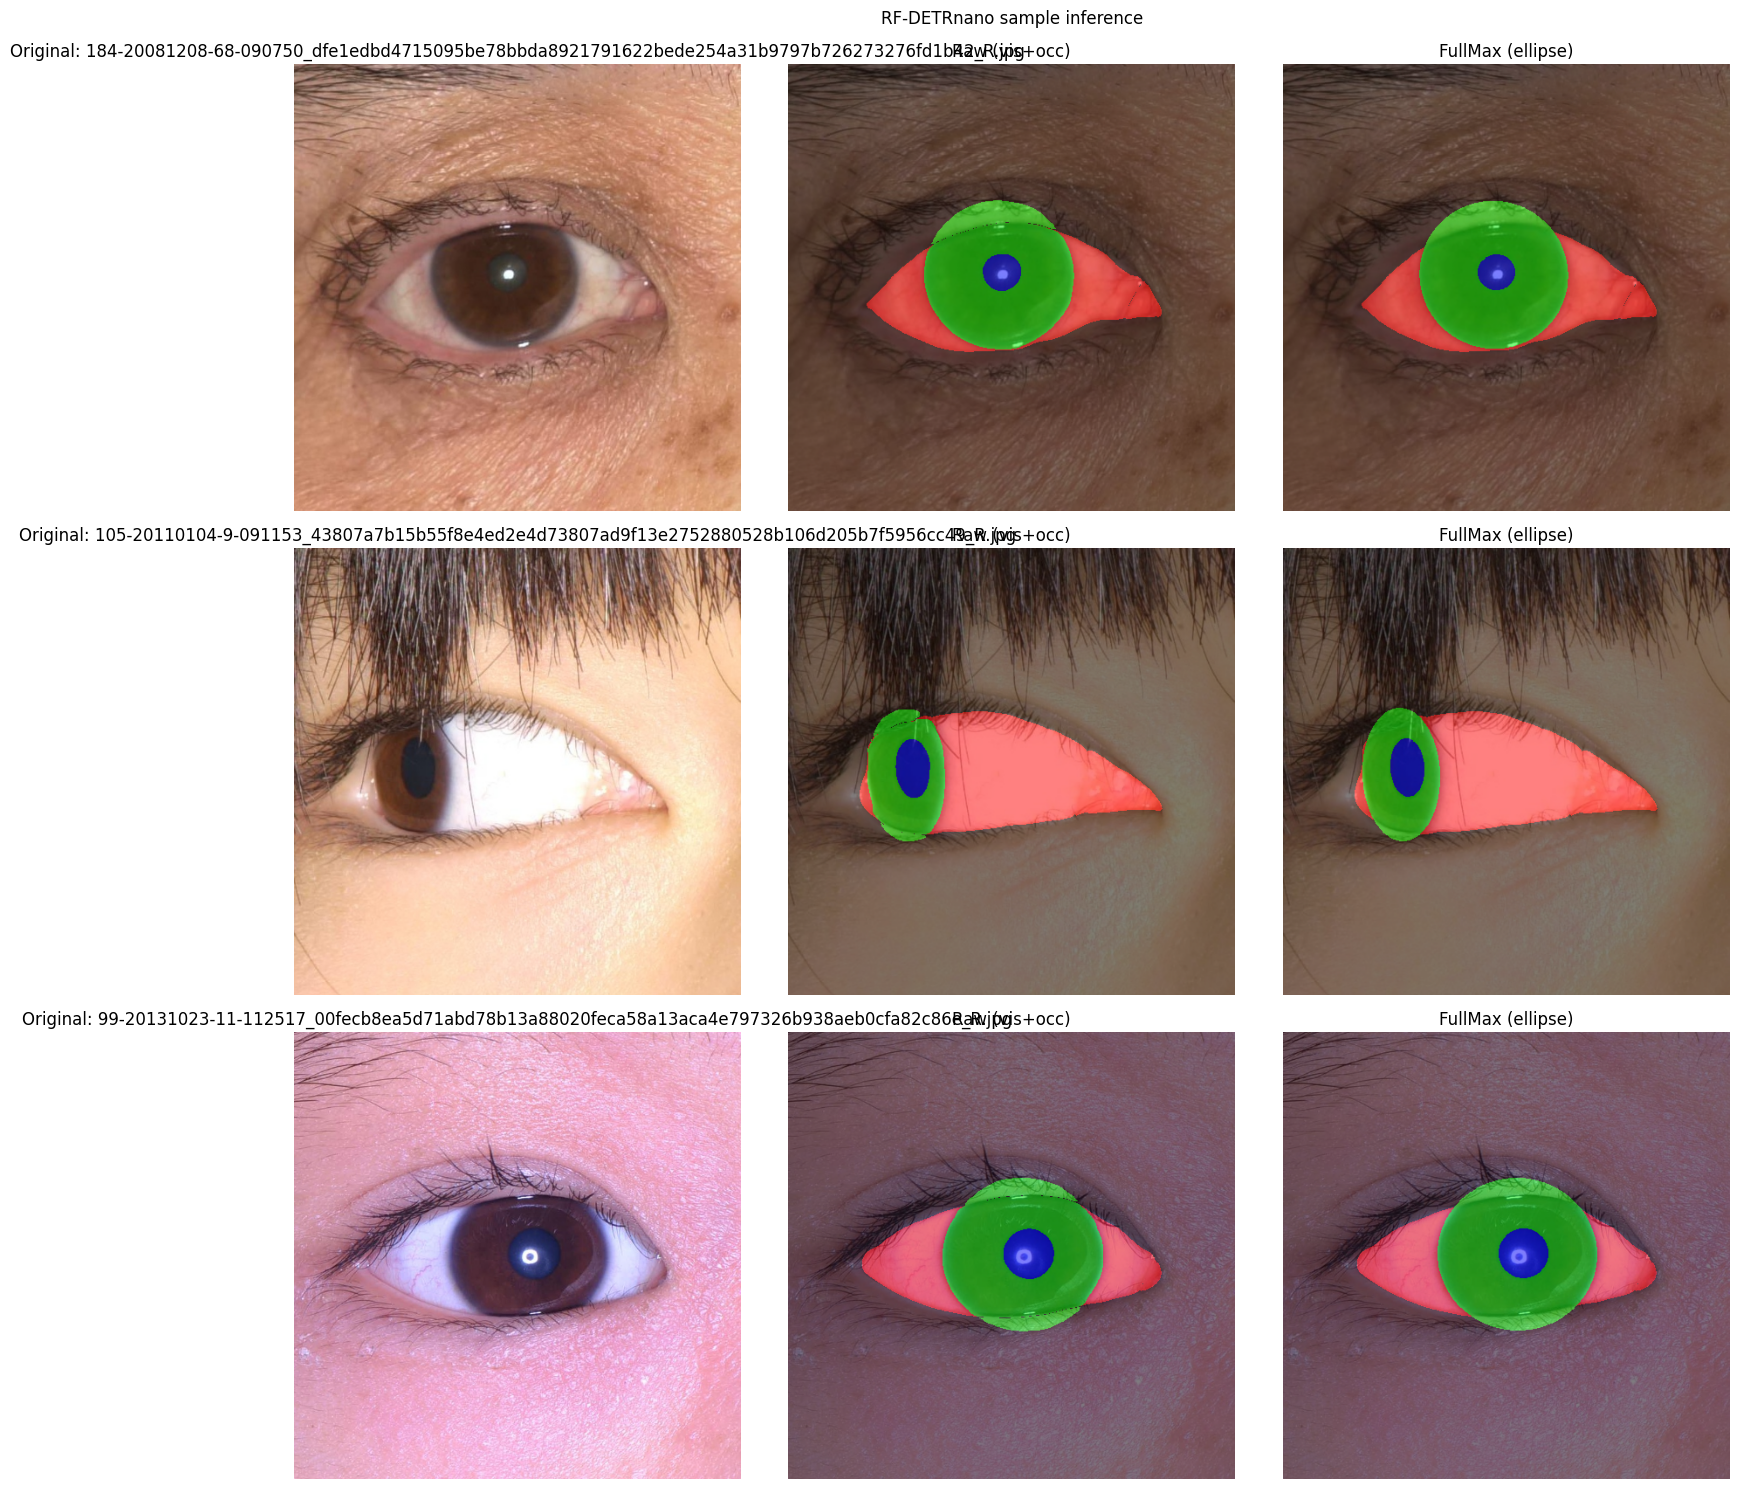

In [ ]:
# ===== 推論（通常版） =====
# このセルは学習済みモデルをそのまま使用する標準的な推論バージョンです。
#
# 【最適化版（Cell 11）との違い】
# - optimize_for_inference() を呼び出さない（torch.compile未使用）
# - 初回実行が速い（コンパイル待ち時間なし）
# - 繰り返し推論では最適化版より遅い
# - デバッグ・テスト向け
#
# 【使い分け】
# - 数枚の画像を試すだけ → この通常版
# - 大量画像の推論・ベンチマーク → 最適化版（Cell 11）

import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# rfdetr はこのセル単体実行でも必須
try:
    from rfdetr import RFDETRSegPreview
except ImportError as e:
    raise ImportError(
        "rfdetr が見つかりません。先に `pip install rfdetr` を実行してください。"
    ) from e

# ===== このセル単体実行のためのデフォルト値 =====
PROJECT_ROOT = globals().get("PROJECT_ROOT")
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path(".").resolve()

OUTPUT_DIR = globals().get("OUTPUT_DIR")
if OUTPUT_DIR is None:
    OUTPUT_DIR = PROJECT_ROOT / "Ablation_RFDETR"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = globals().get("IMAGE_SIZE")
if IMAGE_SIZE is None:
    IMAGE_SIZE = 512
IMAGE_SIZE = int(IMAGE_SIZE)

IMAGES_DIR = globals().get("IMAGES_DIR")
if IMAGES_DIR is None:
    IMAGES_DIR = PROJECT_ROOT / "Images" / "images"

CLASS_NAMES = globals().get("CLASS_NAMES")
if CLASS_NAMES is None:
    CLASS_NAMES = {
        0: "conj",
        1: "caruncle",
        2: "iris_vis",
        3: "iris_occ",
        4: "pupil_vis",
        5: "pupil_occ",
    }

OUTPUT_DIR_TRAIN = globals().get("OUTPUT_DIR_TRAIN")
if OUTPUT_DIR_TRAIN is None:
    OUTPUT_DIR_TRAIN = OUTPUT_DIR / "runs" / "rfdetr_5class"

# ===== 推論設定 =====
RUN_INFER = True  # 推論を実行する場合は True に設定

# チェックポイントパス（トレーニング完了後に更新）
# OUTPUT_DIR_TRAINが未定義の場合は定義
if 'OUTPUT_DIR_TRAIN' not in globals() or OUTPUT_DIR_TRAIN is None:
    OUTPUT_DIR_TRAIN = OUTPUT_DIR / 'runs' / 'rfdetr_5class'

CHECKPOINT_TYPE = "best_total"  # "latest", "best_ema", "best_regular", "best_total"
checkpoint_files = {
    "latest": "checkpoint.pth",
    "best_ema": "checkpoint_best_ema.pth",
    "best_regular": "checkpoint_best_regular.pth",
    "best_total": "checkpoint_best_total.pth"
}
WEIGHTS_PATH = OUTPUT_DIR_TRAIN / checkpoint_files[CHECKPOINT_TYPE]


def _resolve_image_path(name: str) -> Path:
    """Images/images 配下を優先して画像パスを解決"""
    candidates = [
        IMAGES_DIR / name,
        PROJECT_ROOT / "Images" / name,
        PROJECT_ROOT / "Images" / "images" / name,
    ]
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]


def _load_checkpoint_into_rfdetr(model: RFDETRSegPreview, ckpt: dict):
    """rfdetrのチェックポイント辞書をモデルにロードする（既に読み込まれたチェックポイントを受け取る）"""
    ckpt_args = ckpt.get("args", None)

    seg_flag = getattr(ckpt_args, "segmentation_head", None) if ckpt_args is not None else None
    print(f"Checkpoint: epoch={ckpt.get('epoch', None)}, segmentation_head={seg_flag}")

    import torch.nn as nn

    state_dict = ckpt.get("model", None) or ckpt.get("ema_model", None)
    if state_dict is None:
        raise KeyError("Checkpoint does not contain 'model' or 'ema_model'.")

    # RFDETRNano -> self.model (rfdetr.main.Model) -> self.model.model (torch nn.Module)
    if hasattr(model, "model") and hasattr(model.model, "model"):
        core = model.model.model
    elif hasattr(model, "model"):
        core = model.model
    else:
        core = model

    # NOTE: チェックポイントのクラス数に合わせて分類ヘッドを差し替えてからロードする。
    target_num_classes = None
    if "class_embed.weight" in state_dict:
        target_num_classes = int(state_dict["class_embed.weight"].shape[0])
    elif "class_embed.bias" in state_dict:
        target_num_classes = int(state_dict["class_embed.bias"].shape[0])

    if target_num_classes is not None:
        # class_embed
        if hasattr(core, "class_embed") and isinstance(core.class_embed, nn.Linear):
            old = core.class_embed
            if getattr(old, "out_features", None) != target_num_classes:
                new = nn.Linear(old.in_features, target_num_classes, bias=(old.bias is not None))
                new = new.to(device=old.weight.device, dtype=old.weight.dtype)
                core.class_embed = new

        # transformer.enc_out_class_embed (ModuleList[Linear] expected)
        if hasattr(core, "transformer") and hasattr(core.transformer, "enc_out_class_embed"):
            enc = core.transformer.enc_out_class_embed
            if hasattr(enc, "__len__"):
                for i in range(len(enc)):
                    layer = enc[i]
                    if isinstance(layer, nn.Linear) and layer.out_features != target_num_classes:
                        new = nn.Linear(layer.in_features, target_num_classes, bias=(layer.bias is not None))
                        new = new.to(device=layer.weight.device, dtype=layer.weight.dtype)
                        enc[i] = new

        print(f"Adjusted classification heads to num_classes={target_num_classes} before loading checkpoint.")

    core.load_state_dict(state_dict, strict=False)
    core.eval()

    return ckpt_args


def ellipse_mask_from_full_max_contour(vis_255: np.ndarray, occ_255: np.ndarray):
    """可視部分と遮蔽部分から楕円マスクを生成（FullMax後処理）"""
    h, w = vis_255.shape
    vis_255 = (vis_255 > 0).astype(np.uint8) * 255
    occ_255 = (occ_255 > 0).astype(np.uint8) * 255
    full_255 = cv2.bitwise_or(vis_255, occ_255)
    m = (full_255 > 0).astype(np.uint8)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return np.zeros((h, w), dtype=np.uint8)
    cnt = max(cnts, key=cv2.contourArea)
    pts = cnt.reshape(-1, 2).astype(np.float32)
    if len(pts) < 5:
        return np.zeros((h, w), dtype=np.uint8)
    try:
        ellipse = cv2.fitEllipse(pts)
    except Exception:
        return np.zeros((h, w), dtype=np.uint8)
    mask = np.zeros((h, w), dtype=np.uint8)
    (cx, cy), (w_e, h_e), angle = ellipse
    center = (int(cx), int(cy))
    axes = (max(1, int(w_e / 2)), max(1, int(h_e / 2)))
    cv2.ellipse(mask, center, axes, float(angle), 0, 360, 255, thickness=-1)
    return mask


def predict_rfdetr_class_masks(
    model: RFDETRSegPreview,
    image_path: Path,
    image_size: int | None = None,
    threshold: float = 0.25,
    fallback_to_box_masks: bool = True,
):
    """RF-DETRで推論し、クラスごとのmask(255)を返す。クラスIDは0始まり前提。"""
    if image_size is None:
        image_size = IMAGE_SIZE

    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img_resized = cv2.resize(img, (image_size, image_size))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    detections = model.predict(img_rgb, threshold=threshold)

    class_masks = {cid: np.zeros((image_size, image_size), dtype=np.uint8) for cid in CLASS_NAMES.keys()}

    det_mask = getattr(detections, "mask", None)
    if det_mask is not None:
        # det_mask: (N,H,W)
        for m, cls_id in zip(det_mask, detections.class_id):
            cid = int(cls_id)
            if cid not in class_masks:
                continue
            class_masks[cid] = np.maximum(class_masks[cid], (m > 0).astype(np.uint8) * 255)
        return class_masks

    # ここに来る場合：チェックポイントがsegmentation_head=Falseで学習されており、maskが返っていない
    if fallback_to_box_masks:
        for box, cls_id in zip(detections.xyxy, detections.class_id):
            cid = int(cls_id)
            if cid not in class_masks:
                continue
            x1, y1, x2, y2 = box.astype(int)
            x1 = max(0, min(image_size - 1, x1))
            y1 = max(0, min(image_size - 1, y1))
            x2 = max(0, min(image_size - 1, x2))
            y2 = max(0, min(image_size - 1, y2))
            if x2 > x1 and y2 > y1:
                cv2.rectangle(class_masks[cid], (x1, y1), (x2, y2), 255, thickness=-1)

    return class_masks


def make_overlay(img_rgb, lid, iris, pupil, alpha=0.5):
    """画像にマスクをオーバーレイ"""
    h, w = img_rgb.shape[:2]
    color = np.zeros((h, w, 3), dtype=np.uint8)
    color[lid > 0] = (255, 0, 0)  # 眼瞼: 赤
    color[iris > 0] = (0, 255, 0)  # 虹彩: 緑
    color[pupil > 0] = (0, 0, 255)  # 瞳孔: 青
    overlay = cv2.addWeighted(img_rgb, 1 - alpha, color, alpha, 0)
    return overlay


def visualize_samples(model, sample_names, title_prefix="RF-DETRnano"):
    """サンプル画像の推論結果を可視化"""
    n = len(sample_names)
    fig, axes = plt.subplots(n, 4, figsize=(20, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row, name in enumerate(sample_names):
        img_path = _resolve_image_path(name)
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE)), cv2.COLOR_BGR2RGB)

        class_masks = predict_rfdetr_class_masks(model, img_path)

        # 0-indexed: 0=conj, 1=caruncle, 2=iris_vis, 3=iris_occ, 4=pupil_vis, 5=pupil_occ
        conj = class_masks.get(0, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
        caruncle = class_masks.get(1, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
        iris_vis = class_masks.get(2, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
        iris_occ = class_masks.get(3, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
        pupil_vis = class_masks.get(4, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
        pupil_occ = class_masks.get(5, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))

        # eyelid = conj + caruncle（可視化用）
        lid = ((conj > 0) | (caruncle > 0)).astype(np.uint8) * 255

        iris_raw = ((iris_vis > 0) | (iris_occ > 0)).astype(np.uint8) * 255
        pupil_raw = ((pupil_vis > 0) | (pupil_occ > 0)).astype(np.uint8) * 255

        iris_fullmax = ellipse_mask_from_full_max_contour(iris_vis, iris_occ)
        pupil_fullmax = ellipse_mask_from_full_max_contour(pupil_vis, pupil_occ)

        # ユーザー要望: conj + iris_vis + pupil_vis の集合マスク
        union_vis = ((conj > 0) | (iris_vis > 0) | (pupil_vis > 0)).astype(np.uint8) * 255

        overlay_raw = make_overlay(img_rgb, lid, iris_raw, pupil_raw)
        overlay_fullmax = make_overlay(img_rgb, lid, iris_fullmax, pupil_fullmax)

        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"Original: {name}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(overlay_raw)
        axes[row, 1].set_title("Raw (vis+occ)")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay_fullmax)
        axes[row, 2].set_title("FullMax (ellipse)")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(union_vis, cmap="gray", vmin=0, vmax=255)
        axes[row, 3].set_title("Union mask (conj + iris_vis + pupil_vis)")
        axes[row, 3].axis("off")

    plt.suptitle(f"{title_prefix} sample inference", y=0.99)
    plt.tight_layout()
    plt.show()


if RUN_INFER:
    if not WEIGHTS_PATH.exists():
        raise FileNotFoundError(f"Weights not found: {WEIGHTS_PATH}")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading model from: {WEIGHTS_PATH} (device={device})")

    # チェックポイントからnum_classesを先に読み取る
    ckpt = torch.load(str(WEIGHTS_PATH), map_location="cpu", weights_only=False)
    ckpt_args = ckpt.get("args", None)
    
    # チェックポイントのnum_classesを取得（なければCLASS_NAMESの長さを使用）
    if ckpt_args is not None and hasattr(ckpt_args, "num_classes"):
        num_classes_ckpt = ckpt_args.num_classes
    else:
        # チェックポイントのstate_dictから推測
        state_dict = ckpt.get("model", None) or ckpt.get("ema_model", None)
        if state_dict is not None and "class_embed.bias" in state_dict:
            num_classes_ckpt = state_dict["class_embed.bias"].shape[0]
        else:
            num_classes_ckpt = len(CLASS_NAMES)
    
    # チェックポイントのresolutionを取得（なければIMAGE_SIZEを使用）
    if ckpt_args is not None and hasattr(ckpt_args, "resolution"):
        resolution_ckpt = ckpt_args.resolution
    else:
        resolution_ckpt = IMAGE_SIZE
    
    print(f"Checkpoint: num_classes={num_classes_ckpt}, resolution={resolution_ckpt}")
    
    # チェックポイントの設定に合わせてモデルを初期化
    model = RFDETRSegPreview(device=device, resolution=resolution_ckpt)
    # 分類ヘッドをチェックポイント（またはデータセット）のクラス数に合わせる（no-object込み）
    model.model.reinitialize_detection_head(int(num_classes_ckpt) + 1)

    ckpt_args = _load_checkpoint_into_rfdetr(model, ckpt)

    if ckpt_args is not None and getattr(ckpt_args, "segmentation_head", False) is False:
        print(
            "WARNING: このチェックポイントは segmentation_head=False で学習されているため、\n"
            "         推論でmaskが返りません（detections.mask=None）。\n"
            "         いまはbboxから擬似マスク（矩形）を作って表示しています。\n"
            "         本物のマスクが必要なら、学習セルで segmentation_head=True で再学習してください。"
        )

    # サンプル画像を選択（validationセットからランダムに選ぶ）
    if 'val_names' in globals() and len(val_names) > 0:
        num_samples = min(3, len(val_names))
        sample_names = random.sample(val_names, k=num_samples)
        print(f"Selected {num_samples} random samples from validation set ({len(val_names)} images)")
    else:
        # val_namesが未定義の場合はフォールバック
        all_images = list(IMAGES_DIR.glob('*.jpg')) + list(IMAGES_DIR.glob('*.png'))
        if len(all_images) > 0:
            num_samples = min(3, len(all_images))
            sample_names = [p.name for p in random.sample(all_images, k=num_samples)]
            print(f"Warning: val_names not found. Selected {num_samples} random samples from {IMAGES_DIR}")
        else:
            sample_names = []
            print("Warning: No images found")

    print(f"Running inference on {len(sample_names)} samples...")
    visualize_samples(model, sample_names)
else:
    print("推論を実行するには RUN_INFER=True に設定してください。")
    print(f"チェックポイントパス: {WEIGHTS_PATH}")


Loading model from: C:\Users\CorneAI\Eyelid_Iris_pupil_seg_comparison\Ablation_RFDETR\runs\rfdetr_5class\checkpoint_best_total.pth (device=cuda)
Using optimized inference mode...
Checkpoint: num_classes=6, resolution=504
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Checkpoint: epoch=None, segmentation_head=True
Adjusted classification heads to num_classes=6 before loading checkpoint.
Optimizing model for inference...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Model optimization completed!
Running optimized inference on 3 samples...


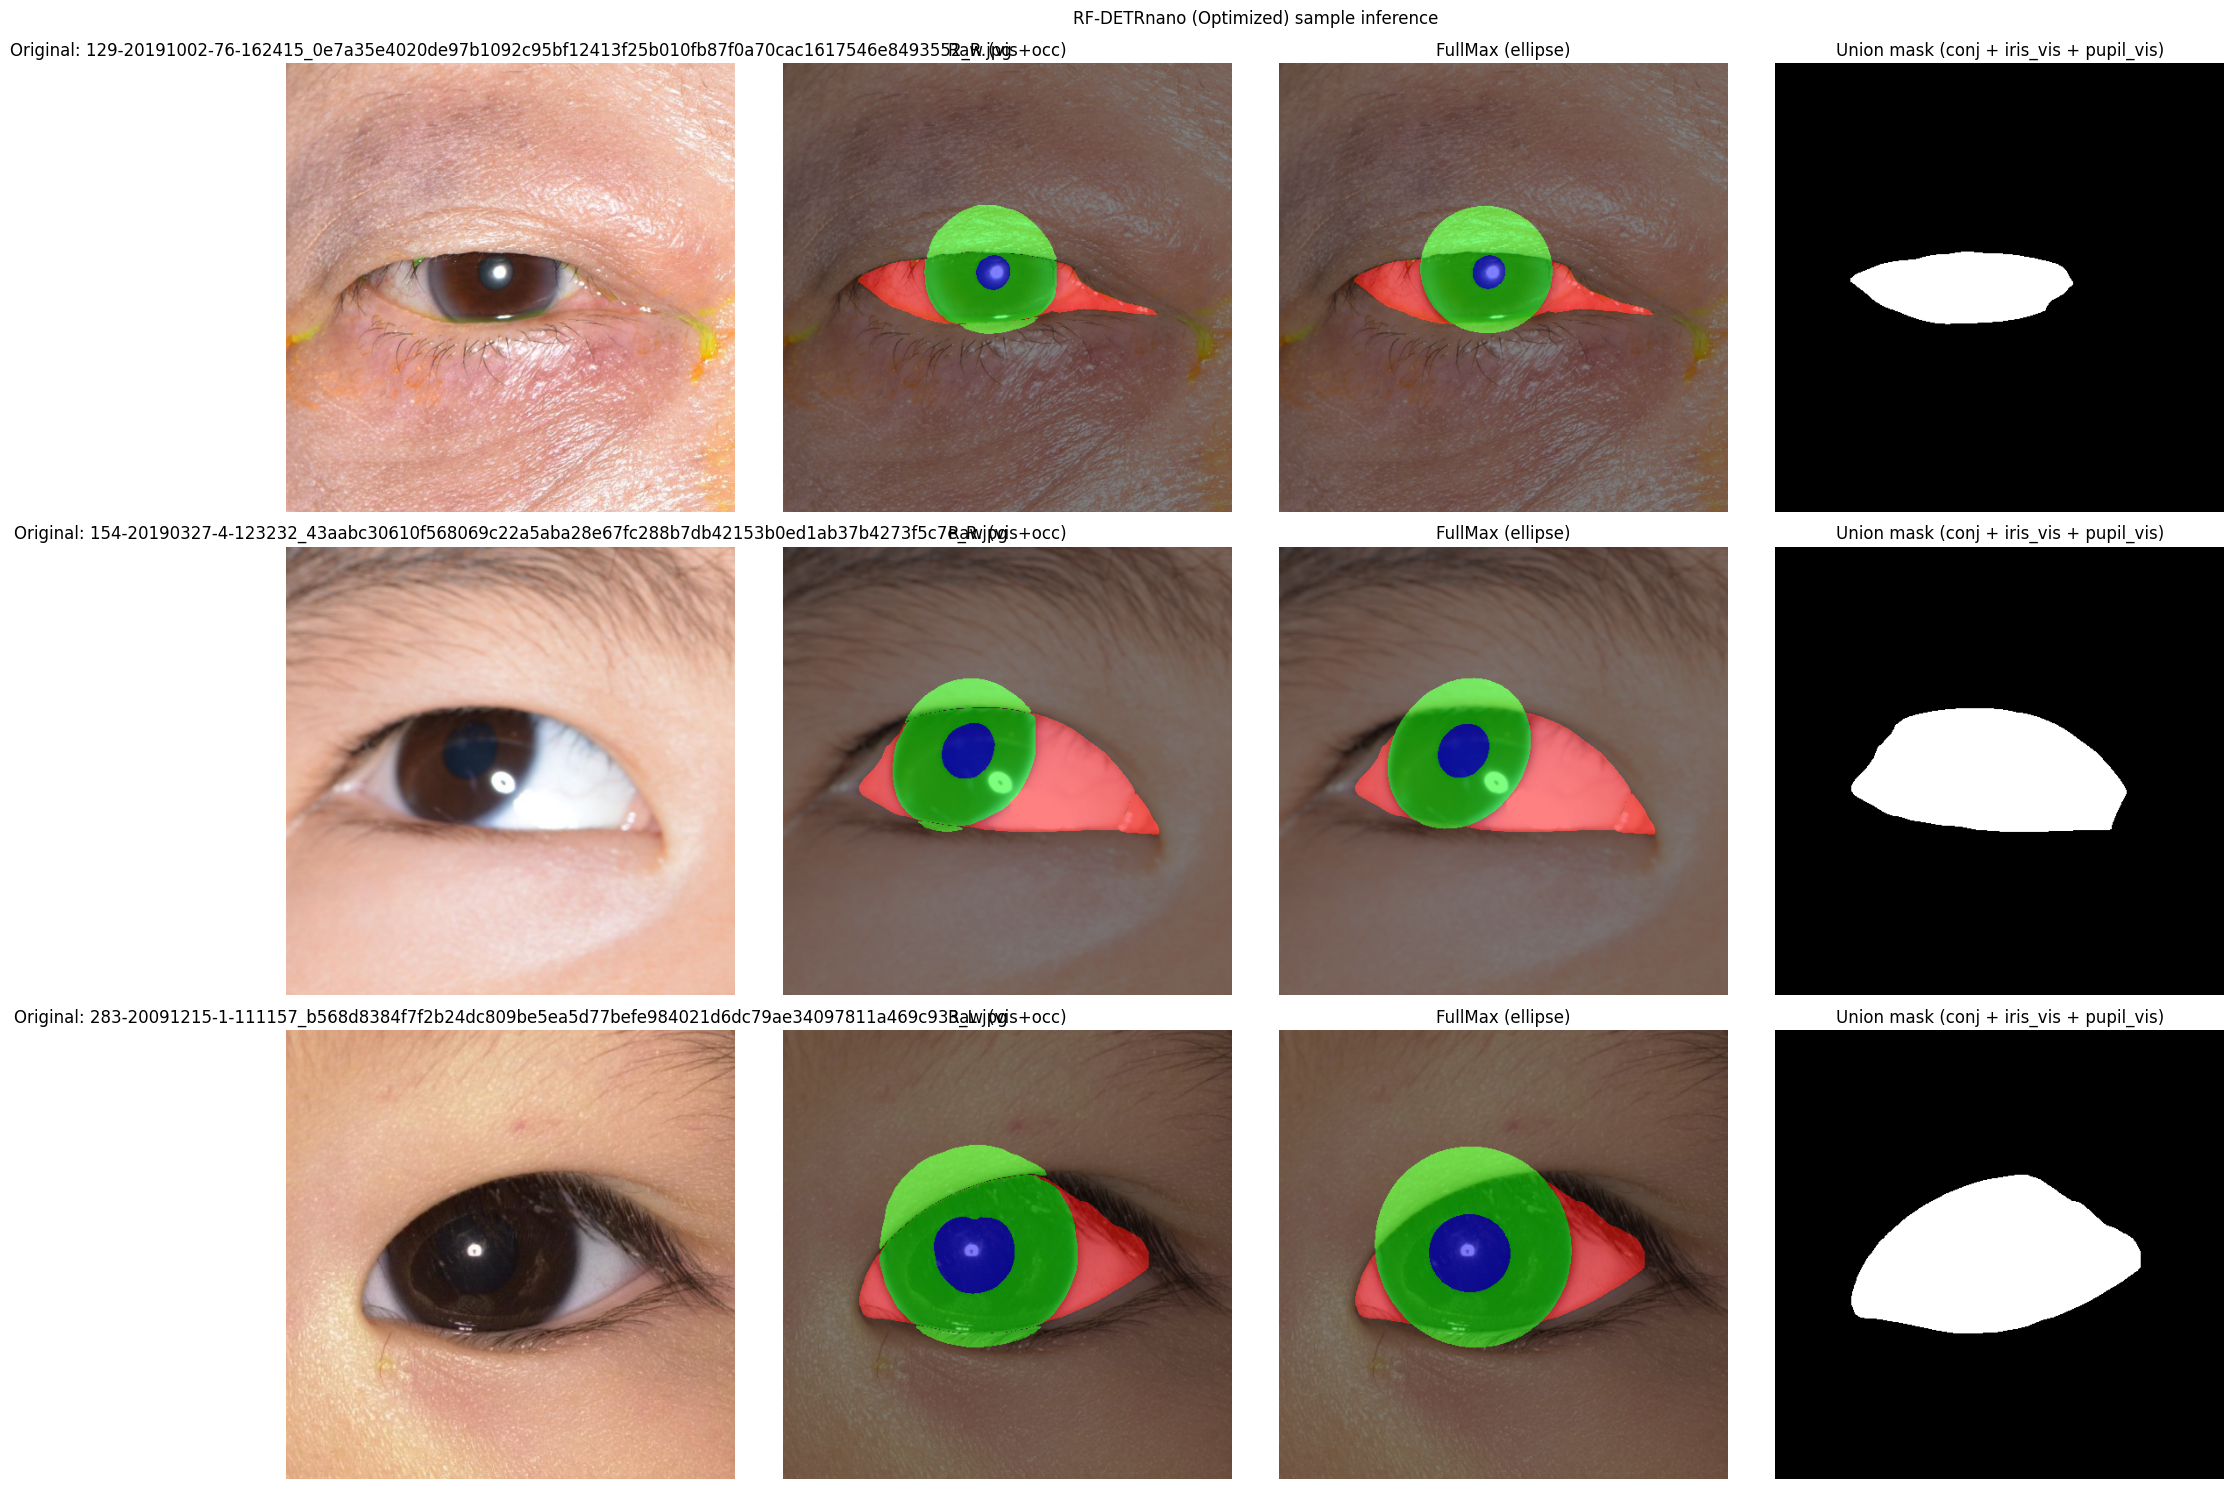

In [1]:
# ===== 推論（最適化版） =====
# このセルは optimize_for_inference() を適用した高速推論バージョンです。
# このセル単体で実行できるように、必要な import / 変数 / 関数をここで補完します。
#
# 【通常版（Cell 10）との違い】
# - optimize_for_inference(compile=True) で torch.compile による最適化を適用
# - 初回実行時にコンパイルのため数十秒〜数分かかる
# - コンパイル後は推論が高速化（特に繰り返し推論時）
# - 本番環境・大量画像処理向け
#
# 【使い分け】
# - 数枚の画像を試すだけ → 通常版（Cell 10）
# - 大量画像の推論・ベンチマーク → この最適化版

from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# rfdetr はこのセル単体実行でも必須
try:
    from rfdetr import RFDETRSegPreview
except ImportError as e:
    raise ImportError(
        "rfdetr が見つかりません。先に `pip install rfdetr` を実行してください。"
    ) from e

# ===== このセル単体実行のためのデフォルト値 =====
PROJECT_ROOT = globals().get("PROJECT_ROOT")
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path(".").resolve()

OUTPUT_DIR = globals().get("OUTPUT_DIR")
if OUTPUT_DIR is None:
    OUTPUT_DIR = PROJECT_ROOT / "Ablation_RFDETR"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = globals().get("IMAGE_SIZE")
if IMAGE_SIZE is None:
    IMAGE_SIZE = 512
IMAGE_SIZE = int(IMAGE_SIZE)

IMAGES_DIR = globals().get("IMAGES_DIR")
if IMAGES_DIR is None:
    IMAGES_DIR = PROJECT_ROOT / "Images" / "images"

CLASS_NAMES = globals().get("CLASS_NAMES")
if CLASS_NAMES is None:
    CLASS_NAMES = {
        0: "conj",
        1: "caruncle",
        2: "iris_vis",
        3: "iris_occ",
        4: "pupil_vis",
        5: "pupil_occ",
    }

OUTPUT_DIR_TRAIN = globals().get("OUTPUT_DIR_TRAIN")
if OUTPUT_DIR_TRAIN is None:
    OUTPUT_DIR_TRAIN = OUTPUT_DIR / "runs" / "rfdetr_5class"


# ===== 未定義ならヘルパ関数を補完（Cell 10 を未実行でも動くように） =====
if "_resolve_image_path" not in globals():

    def _resolve_image_path(name: str) -> Path:
        """Images/images 配下を優先して画像パスを解決"""
        candidates = [
            IMAGES_DIR / name,
            PROJECT_ROOT / "Images" / name,
            PROJECT_ROOT / "Images" / "images" / name,
        ]
        for p in candidates:
            if p.exists():
                return p
        return candidates[0]


if "_load_checkpoint_into_rfdetr" not in globals():

    def _load_checkpoint_into_rfdetr(model: RFDETRSegPreview, ckpt: dict):
        """rfdetrのチェックポイント辞書をモデルにロードする（既に読み込まれたチェックポイントを受け取る）"""
        ckpt_args = ckpt.get("args", None)
        seg_flag = getattr(ckpt_args, "segmentation_head", None) if ckpt_args is not None else None
        print(f"Checkpoint: epoch={ckpt.get('epoch', None)}, segmentation_head={seg_flag}")

        import torch.nn as nn

        state_dict = ckpt.get("model", None) or ckpt.get("ema_model", None)
        if state_dict is None:
            raise KeyError("Checkpoint does not contain 'model' or 'ema_model'.")

        if hasattr(model, "model") and hasattr(model.model, "model"):
            core = model.model.model
        elif hasattr(model, "model"):
            core = model.model
        else:
            core = model

        target_num_classes = None
        if "class_embed.weight" in state_dict:
            target_num_classes = int(state_dict["class_embed.weight"].shape[0])
        elif "class_embed.bias" in state_dict:
            target_num_classes = int(state_dict["class_embed.bias"].shape[0])

        if target_num_classes is not None:
            if hasattr(core, "class_embed") and isinstance(core.class_embed, nn.Linear):
                old = core.class_embed
                if getattr(old, "out_features", None) != target_num_classes:
                    new = nn.Linear(old.in_features, target_num_classes, bias=(old.bias is not None))
                    new = new.to(device=old.weight.device, dtype=old.weight.dtype)
                    core.class_embed = new

            if hasattr(core, "transformer") and hasattr(core.transformer, "enc_out_class_embed"):
                enc = core.transformer.enc_out_class_embed
                if hasattr(enc, "__len__"):
                    for i in range(len(enc)):
                        layer = enc[i]
                        if isinstance(layer, nn.Linear) and layer.out_features != target_num_classes:
                            new = nn.Linear(layer.in_features, target_num_classes, bias=(layer.bias is not None))
                            new = new.to(device=layer.weight.device, dtype=layer.weight.dtype)
                            enc[i] = new

            print(f"Adjusted classification heads to num_classes={target_num_classes} before loading checkpoint.")

        core.load_state_dict(state_dict, strict=False)
        core.eval()
        return ckpt_args


if "ellipse_mask_from_full_max_contour" not in globals():

    def ellipse_mask_from_full_max_contour(vis_255: np.ndarray, occ_255: np.ndarray):
        """可視部分と遮蔽部分から楕円マスクを生成（FullMax後処理）"""
        h, w = vis_255.shape
        vis_255 = (vis_255 > 0).astype(np.uint8) * 255
        occ_255 = (occ_255 > 0).astype(np.uint8) * 255
        full_255 = cv2.bitwise_or(vis_255, occ_255)
        m = (full_255 > 0).astype(np.uint8)
        cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        if not cnts:
            return np.zeros((h, w), dtype=np.uint8)
        cnt = max(cnts, key=cv2.contourArea)
        pts = cnt.reshape(-1, 2).astype(np.float32)
        if len(pts) < 5:
            return np.zeros((h, w), dtype=np.uint8)
        try:
            ellipse = cv2.fitEllipse(pts)
        except Exception:
            return np.zeros((h, w), dtype=np.uint8)
        mask = np.zeros((h, w), dtype=np.uint8)
        (cx, cy), (w_e, h_e), angle = ellipse
        center = (int(cx), int(cy))
        axes = (max(1, int(w_e / 2)), max(1, int(h_e / 2)))
        cv2.ellipse(mask, center, axes, float(angle), 0, 360, 255, thickness=-1)
        return mask


if "predict_rfdetr_class_masks" not in globals():

    def predict_rfdetr_class_masks(
        model: RFDETRSegPreview,
        image_path: Path,
        image_size: int | None = None,
        threshold: float = 0.25,
        fallback_to_box_masks: bool = True,
    ):
        """RF-DETRで推論し、クラスごとのmask(255)を返す。クラスIDは0始まり前提。"""
        if image_size is None:
            image_size = IMAGE_SIZE

        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f"Could not read image: {image_path}")

        img_resized = cv2.resize(img, (image_size, image_size))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

        detections = model.predict(img_rgb, threshold=threshold)
        class_masks = {cid: np.zeros((image_size, image_size), dtype=np.uint8) for cid in CLASS_NAMES.keys()}

        det_mask = getattr(detections, "mask", None)
        if det_mask is not None:
            for m, cls_id in zip(det_mask, detections.class_id):
                cid = int(cls_id)
                if cid not in class_masks:
                    continue
                class_masks[cid] = np.maximum(class_masks[cid], (m > 0).astype(np.uint8) * 255)
            return class_masks

        if fallback_to_box_masks:
            for box, cls_id in zip(detections.xyxy, detections.class_id):
                cid = int(cls_id)
                if cid not in class_masks:
                    continue
                x1, y1, x2, y2 = box.astype(int)
                x1 = max(0, min(image_size - 1, x1))
                y1 = max(0, min(image_size - 1, y1))
                x2 = max(0, min(image_size - 1, x2))
                y2 = max(0, min(image_size - 1, y2))
                if x2 > x1 and y2 > y1:
                    cv2.rectangle(class_masks[cid], (x1, y1), (x2, y2), 255, thickness=-1)

        return class_masks


if "make_overlay" not in globals():

    def make_overlay(img_rgb, lid, iris, pupil, alpha=0.5):
        """画像にマスクをオーバーレイ"""
        h, w = img_rgb.shape[:2]
        color = np.zeros((h, w, 3), dtype=np.uint8)
        color[lid > 0] = (255, 0, 0)  # 眼瞼: 赤
        color[iris > 0] = (0, 255, 0)  # 虹彩: 緑
        color[pupil > 0] = (0, 0, 255)  # 瞳孔: 青
        overlay = cv2.addWeighted(img_rgb, 1 - alpha, color, alpha, 0)
        return overlay


if "visualize_samples" not in globals():

    def visualize_samples(model, sample_names, title_prefix="RF-DETRnano"):
        """サンプル画像の推論結果を可視化"""
        n = len(sample_names)
        fig, axes = plt.subplots(n, 4, figsize=(20, 5 * n))
        if n == 1:
            axes = axes.reshape(1, -1)

        for row, name in enumerate(sample_names):
            img_path = _resolve_image_path(name)
            img_bgr = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE)), cv2.COLOR_BGR2RGB)

            class_masks = predict_rfdetr_class_masks(model, img_path)

            conj = class_masks.get(0, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
            caruncle = class_masks.get(1, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
            iris_vis = class_masks.get(2, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
            iris_occ = class_masks.get(3, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
            pupil_vis = class_masks.get(4, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))
            pupil_occ = class_masks.get(5, np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8))

            lid = ((conj > 0) | (caruncle > 0)).astype(np.uint8) * 255
            iris_raw = ((iris_vis > 0) | (iris_occ > 0)).astype(np.uint8) * 255
            pupil_raw = ((pupil_vis > 0) | (pupil_occ > 0)).astype(np.uint8) * 255

            iris_fullmax = ellipse_mask_from_full_max_contour(iris_vis, iris_occ)
            pupil_fullmax = ellipse_mask_from_full_max_contour(pupil_vis, pupil_occ)

            # ユーザー要望: conj + iris_vis + pupil_vis の集合マスク
            union_vis = ((conj > 0) | (iris_vis > 0) | (pupil_vis > 0)).astype(np.uint8) * 255

            overlay_raw = make_overlay(img_rgb, lid, iris_raw, pupil_raw)
            overlay_fullmax = make_overlay(img_rgb, lid, iris_fullmax, pupil_fullmax)

            axes[row, 0].imshow(img_rgb)
            axes[row, 0].set_title(f"Original: {name}")
            axes[row, 0].axis("off")

            axes[row, 1].imshow(overlay_raw)
            axes[row, 1].set_title("Raw (vis+occ)")
            axes[row, 1].axis("off")

            axes[row, 2].imshow(overlay_fullmax)
            axes[row, 2].set_title("FullMax (ellipse)")
            axes[row, 2].axis("off")

            axes[row, 3].imshow(union_vis, cmap="gray", vmin=0, vmax=255)
            axes[row, 3].set_title("Union mask (conj + iris_vis + pupil_vis)")
            axes[row, 3].axis("off")

        plt.suptitle(f"{title_prefix} sample inference", y=0.99)
        plt.tight_layout()
        plt.show()


# ===== 実行 =====
CHECKPOINT_TYPE = "best_total"  # "latest", "best_ema", "best_regular", "best_total"
checkpoint_files = {
    "latest": "checkpoint.pth",
    "best_ema": "checkpoint_best_ema.pth",
    "best_regular": "checkpoint_best_regular.pth",
    "best_total": "checkpoint_best_total.pth",
}
WEIGHTS_PATH = OUTPUT_DIR_TRAIN / checkpoint_files[CHECKPOINT_TYPE]

RUN_INFER_OPTIMIZED = True  # 最適化版推論を実行する場合は True に設定

if RUN_INFER_OPTIMIZED:
    if not WEIGHTS_PATH.exists():
        raise FileNotFoundError(f"Weights not found: {WEIGHTS_PATH}")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading model from: {WEIGHTS_PATH} (device={device})")
    print("Using optimized inference mode...")

    ckpt = torch.load(str(WEIGHTS_PATH), map_location="cpu", weights_only=False)
    ckpt_args = ckpt.get("args", None)

    if ckpt_args is not None and hasattr(ckpt_args, "num_classes"):
        num_classes_ckpt = ckpt_args.num_classes
    else:
        state_dict = ckpt.get("model", None) or ckpt.get("ema_model", None)
        if state_dict is not None and "class_embed.bias" in state_dict:
            num_classes_ckpt = state_dict["class_embed.bias"].shape[0]
        else:
            num_classes_ckpt = len(CLASS_NAMES)

    if ckpt_args is not None and hasattr(ckpt_args, "resolution"):
        resolution_ckpt = ckpt_args.resolution
    else:
        resolution_ckpt = IMAGE_SIZE

    print(f"Checkpoint: num_classes={num_classes_ckpt}, resolution={resolution_ckpt}")

    model = RFDETRSegPreview(device=device, resolution=resolution_ckpt)
    model.model.reinitialize_detection_head(int(num_classes_ckpt) + 1)

    ckpt_args = _load_checkpoint_into_rfdetr(model, ckpt)

    if ckpt_args is not None and getattr(ckpt_args, "segmentation_head", False) is False:
        print(
            "WARNING: このチェックポイントは segmentation_head=False で学習されているため、\n"
            "         推論でmaskが返りません（detections.mask=None）。\n"
            "         いまはbboxから擬似マスク（矩形）を作って表示しています。\n"
            "         本物のマスクが必要なら、学習セルで segmentation_head=True で再学習してください。"
        )

    print("Optimizing model for inference...")
    model.optimize_for_inference(
        compile=True,
        batch_size=1,
        dtype=torch.float32,
    )
    print("Model optimization completed!")

    if "val_names" in globals() and len(val_names) > 0:
        num_samples = min(3, len(val_names))
        sample_names = random.sample(val_names, k=num_samples)
        print(f"Selected {num_samples} random samples from validation set ({len(val_names)} images)")
    else:
        all_images = list(IMAGES_DIR.glob("*.jpg")) + list(IMAGES_DIR.glob("*.png"))
        if len(all_images) > 0:
            num_samples = min(3, len(all_images))
            sample_names = [p.name for p in random.sample(all_images, k=num_samples)]
            print(f"Warning: val_names not found. Selected {num_samples} random samples from {IMAGES_DIR}")
        else:
            sample_names = []
            print(f"Warning: No images found in {IMAGES_DIR}")

    print(f"Running optimized inference on {len(sample_names)} samples...")
    visualize_samples(model, sample_names, title_prefix="RF-DETRnano (Optimized)")
else:
    print("最適化版推論を実行するには RUN_INFER_OPTIMIZED=True に設定してください。")
    print(f"チェックポイントパス: {WEIGHTS_PATH}")

